In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import random

In [2]:
from nazi_symbols_classification.training.data_preparation import get_image_paths

In [3]:
image_files = get_image_paths("/Users/zhiwei.zhang/Projects/nazi-symbols-classification/notebooks/datasets/nazi-symbols-classification", 
                              ("train", "test", "valid"))

Total Images: 2199


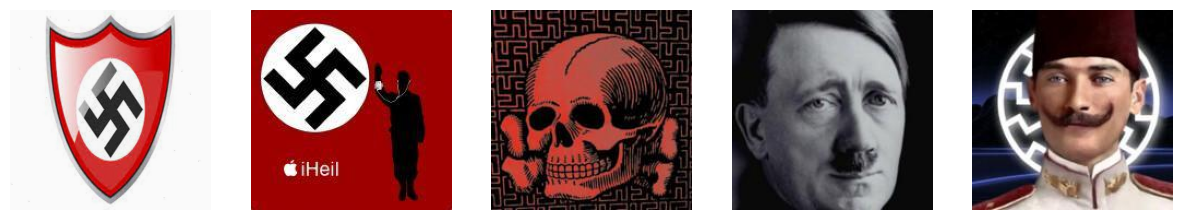

In [4]:
print(f"Total Images: {len(image_files)}")

# Display sample images
sample_images = random.sample(image_files, 5)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, img_file in zip(axes, sample_images):
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
plt.show()

In [5]:
labels = [os.path.basename(os.path.dirname(image_file)) for image_file in image_files]

In [6]:
import pandas as pd

df = pd.DataFrame({"path": image_files, "label": labels})
df.head()

,path,label
0,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,neo_nazi
1,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,neo_nazi
2,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,neo_nazi
3,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,neo_nazi
4,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,neo_nazi


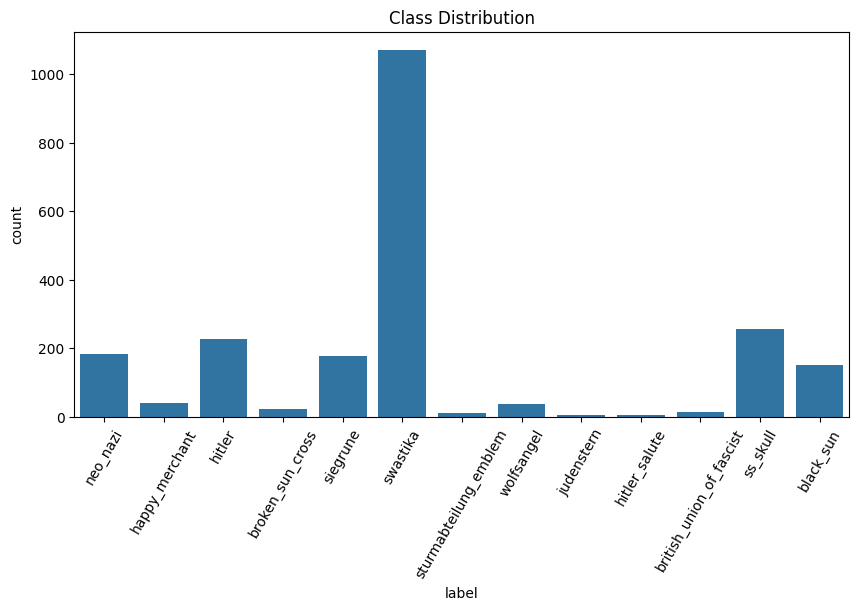

In [12]:
import seaborn as sns

# Plot class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.xticks(rotation=60)
plt.show()

In [13]:
import numpy as np

# Compute mean and std deviation across dataset
means, stds = [], []
for img_file in image_files:
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    means.append(np.mean(img, axis=(0, 1)))
    stds.append(np.std(img, axis=(0, 1)))

means = np.mean(means, axis=0)
stds = np.mean(stds, axis=0)
print(f"Mean: {means}, Std Dev: {stds}")


Mean: [0.47230751 0.40355645 0.39039144], Std Dev: [0.29093835 0.29188609 0.28588228]


In [14]:
def detect_blur(img_path, threshold=100):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var < threshold

blurred_images = [f for f in image_files if detect_blur(f)]
print(f"Blurred Images: {len(blurred_images)}")


Blurred Images: 79


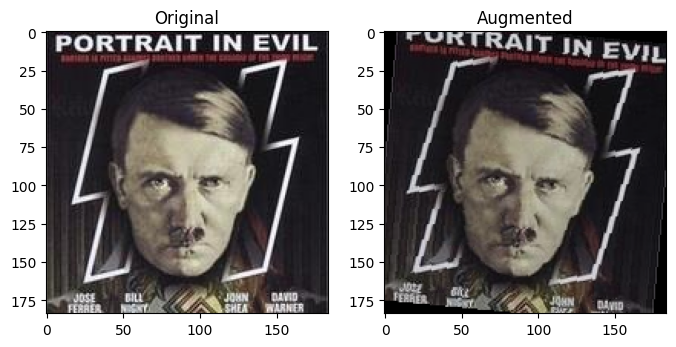

In [15]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

img = Image.open(random.choice(image_files))
augmented_img = transform(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(augmented_img)
plt.title("Augmented")
plt.show()


In [34]:
import torch
from open_clip import create_model_and_transforms
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, _, preprocess = create_model_and_transforms(
    'ViT-B-32', pretrained='/Users/zhiwei.zhang/Projects/nazi-symbols-classification/data/open_clip_pytorch_model.bin',
    cache_dir='/Users/zhiwei.zhang/Projects/nazi-symbols-classification/data', device=device)

img = preprocess(Image.open(image_files[0])).unsqueeze(0).to(device)
features = model.encode_image(img)
print(f"Feature vector shape: {features.shape}")


Feature vector shape: torch.Size([1, 512])


In [43]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=2).fit(features.cpu().detach().numpy())
print(f"Number of outliers: {sum(dbscan.labels_ == -1)}")

Number of outliers: 1
